# [Encuesta de satisfacción en Google Form](https://forms.gle/YUc83ygwGoEcHgM2A) 

Prompt  

Ahora, dame por favor, la implementación de estos conceptos, de este resumen, a un problema de clasificación multiclase asociada a un problema de Administración de Empresas en el contexto del Bajo Cauca Antioqueño.

Excelente, Marco Julio 🌱 — te propongo una **implementación completa en Python (con TensorFlow/Keras)** que aplica los **conceptos del mapa conceptual** (modelo secuencial, preprocesamiento, entrenamiento, evaluación y ajuste) a un **problema de clasificación multiclase** en el **contexto de la Administración de Empresas del Bajo Cauca Antioqueño**.

---

## 🎯 Contexto aplicado

**Problema:**
Una cooperativa agrícola de *Caucasia (Antioquia)* desea **clasificar los tipos de unidades productivas** (pequeña, mediana o grande) a partir de indicadores económicos y de gestión empresarial.

**Variables observadas (features):**

* `ventas_anuales` (en millones de pesos)
* `n_empleados`
* `costos_operativos` (en millones)
* `inversion_en_tecnologia` (% del presupuesto)
* `nivel_endeudamiento` (% del capital)

**Variable objetivo (target):**

* `clase_empresa` (0 = pequeña, 1 = mediana, 2 = grande)

---



## 💡 Objetivo

Entrenar un **clasificador multiclase** que, a partir de los indicadores de una empresa, prediga su categoría empresarial.

---



## 🧠 Implementación en Python (Keras Sequential API)

A continuación te dejo el script listo para usar en Jupyter Notebook o como archivo `.py`:



   ventas_anuales  n_empleados  costos_operativos  inversion_en_tecnologia  \
0      239.737132           49         138.389014                12.667545   
1      188.938856           70         100.825197                17.331739   
2      251.815083           78         158.787901                 8.455481   
3      321.842389          175         232.993847                19.168222   
4      181.267730          132          99.033366                 3.529755   

   nivel_endeudamiento  clase_empresa  
0            42.662545              1  
1            67.170624              1  
2            14.716919              1  
3            37.117481              2  
4            69.628887              1  
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7812 - loss: 0.5711 - val_accuracy: 0.8438 - val_loss: 0.3609
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9010 - loss: 0.2194 - val_accuracy: 0.8958 - val_loss: 0.2460
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0

c:\Users\marco\Documentos\investigacion\intro_ml_dl\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


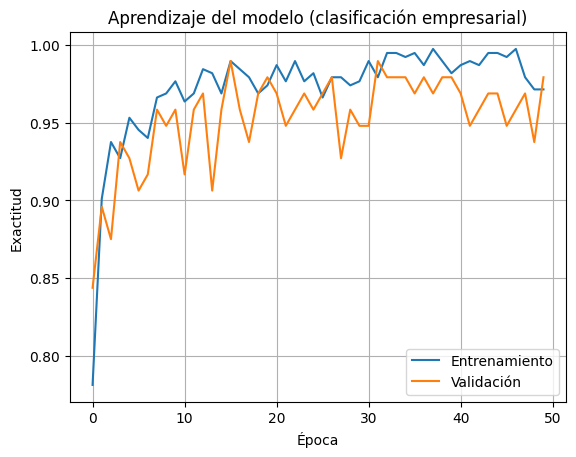

In [1]:
# ===========================================================
# CLASIFICADOR MULTICLASE PARA EMPRESAS DEL BAJO CAUCA
# ===========================================================
# Inspirado en Aurélien Géron, adaptado al contexto regional
# Autor: Marco Julio Cañas
# ===========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

# -----------------------------------------------------------
# 1️⃣ CREACIÓN DEL CONJUNTO DE DATOS (SIMULADO)
# -----------------------------------------------------------

np.random.seed(42)
n = 600  # número de empresas

ventas = np.random.normal(200, 80, n)  # millones
empleados = np.random.randint(3, 200, n)
costos = ventas * np.random.uniform(0.5, 0.9, n)
tecnologia = np.random.uniform(1, 20, n)
endeudamiento = np.random.uniform(10, 80, n)

# Clasificación de empresa (target)
# Pequeña si ventas < 150, Mediana si < 300, Grande si >= 300
clase = np.select(
    [ventas < 150, (ventas >= 150) & (ventas < 300), ventas >= 300],
    [0, 1, 2]
)

df = pd.DataFrame({
    'ventas_anuales': ventas,
    'n_empleados': empleados,
    'costos_operativos': costos,
    'inversion_en_tecnologia': tecnologia,
    'nivel_endeudamiento': endeudamiento,
    'clase_empresa': clase
})

print(df.head())

# -----------------------------------------------------------
# 2️⃣ PREPROCESAMIENTO
# -----------------------------------------------------------

X = df.drop('clase_empresa', axis=1)
y = df['clase_empresa']

# Escalamos las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División train / test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# -----------------------------------------------------------
# 3️⃣ MODELO SECUENCIAL
# -----------------------------------------------------------

model = keras.models.Sequential([
    keras.layers.Input(shape=[X_train.shape[1]]),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(3, activation='softmax')  # 3 clases
])

# -----------------------------------------------------------
# 4️⃣ COMPILACIÓN
# -----------------------------------------------------------

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# -----------------------------------------------------------
# 5️⃣ ENTRENAMIENTO
# -----------------------------------------------------------

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# -----------------------------------------------------------
# 6️⃣ EVALUACIÓN
# -----------------------------------------------------------

loss, accuracy = model.evaluate(X_test, y_test)
print(f'Exactitud del modelo: {accuracy:.2f}')

# -----------------------------------------------------------
# 7️⃣ PREDICCIÓN DE NUEVAS EMPRESAS
# -----------------------------------------------------------

nueva_empresa = np.array([[220, 45, 160, 12, 35]])  # ejemplo de empresa local
nueva_empresa_scaled = scaler.transform(nueva_empresa)
pred = model.predict(nueva_empresa_scaled)
print("Probabilidades:", pred)
print("Clase predicha:", np.argmax(pred))

# -----------------------------------------------------------
# 8️⃣ VISUALIZACIÓN DEL APRENDIZAJE
# -----------------------------------------------------------

plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Aprendizaje del modelo (clasificación empresarial)')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend()
plt.grid(True)
plt.savefig(r"C:\Users\marco\Downloads\clasificacion_empresarial.png")
plt.show()


```

---

## 📊 Interpretación de resultados

* **Exactitud del modelo:** muestra el porcentaje de empresas correctamente clasificadas en los datos de prueba.
* **Curvas de aprendizaje:** permiten observar si el modelo sobreajusta (train >> val).
* **Predicciones:** entregan la probabilidad de pertenecer a cada tipo de empresa.

---

## 🌾 Aplicación educativa y regional

Este ejercicio puede presentarse a **estudiantes de Administración de Empresas** como ejemplo de:

* **Ciencia de datos aplicada al desarrollo regional.**
* **Uso del aprendizaje automático para la toma de decisiones empresariales.**
* **Relación entre indicadores económicos y escalas productivas.**
* **Ética y sostenibilidad empresarial:** cómo los modelos de datos pueden apoyar la formalización y eficiencia de las MIPYMES del Bajo Cauca.

---

¿Quieres que te genere también el **mapa conceptual complementario en Graphviz** adaptado específicamente a este *caso empresarial* (en lugar del ejemplo genérico de Fashion MNIST)? Podría mostrar visualmente cómo se enlazan las etapas: *datos → modelo → entrenamiento → evaluación → toma de decisiones empresariales.*
